# Week 4 exercise — worked solution

In [1]:
import math9102 as m9
import numpy as np
from scipy import stats

m9.use_house_style()

survey = m9.load_survey()
bully = m9.load_bullying()

---

## Question 1 — Perceived stress by sex

### 1.1 Hypotheses

> **H₀:** There is no difference in Total Perceived Stress between men and women.
>
> **H₁:** There is a difference in Total Perceived Stress between men and women.

### 1.2 Inspect

In [2]:
m9.frequency(survey, "sex")

,count,percent,valid_percent
sex,,,
FEMALES,254,57.86,57.86
MALES,185,42.14,42.14


In [3]:
m9.describe_by(survey, "tpstress", "sex")

,n,missing,mean,sd,se,median,iqr,min,max,skew,kurtosis
sex,,,,,,,,,,,
FEMALES,249.0,5.0,27.422,6.066,0.384,27.0,7.0,12.0,44.0,0.173,0.074
MALES,184.0,1.0,25.788,5.414,0.399,25.0,8.0,13.0,46.0,0.271,0.393


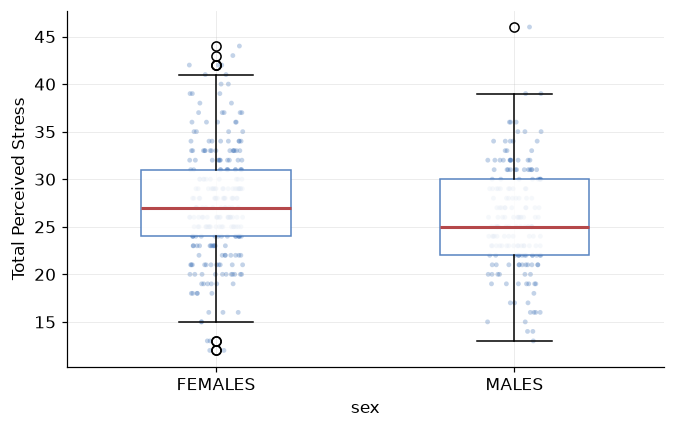

In [4]:
m9.grouped_box(survey, "tpstress", "sex", ylabel="Total Perceived Stress");

### 1.3 Assumptions

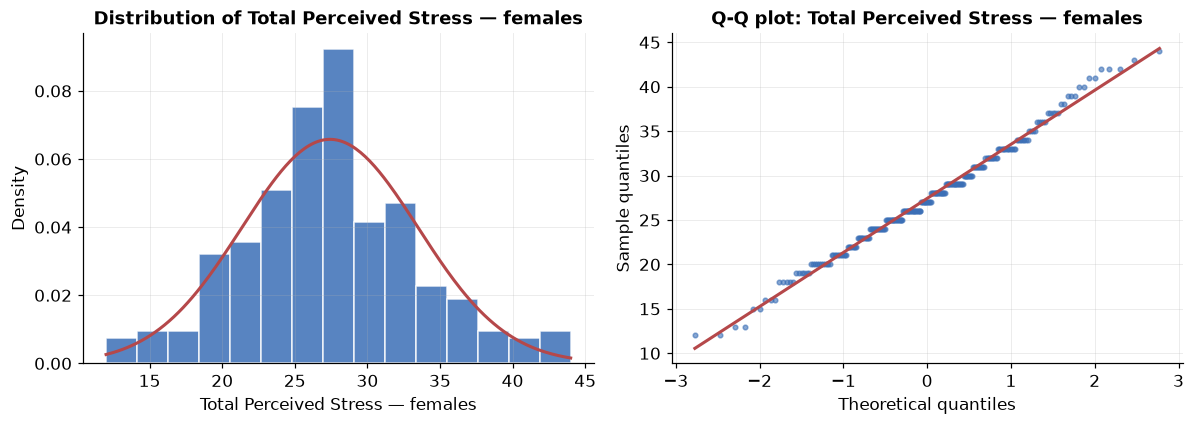

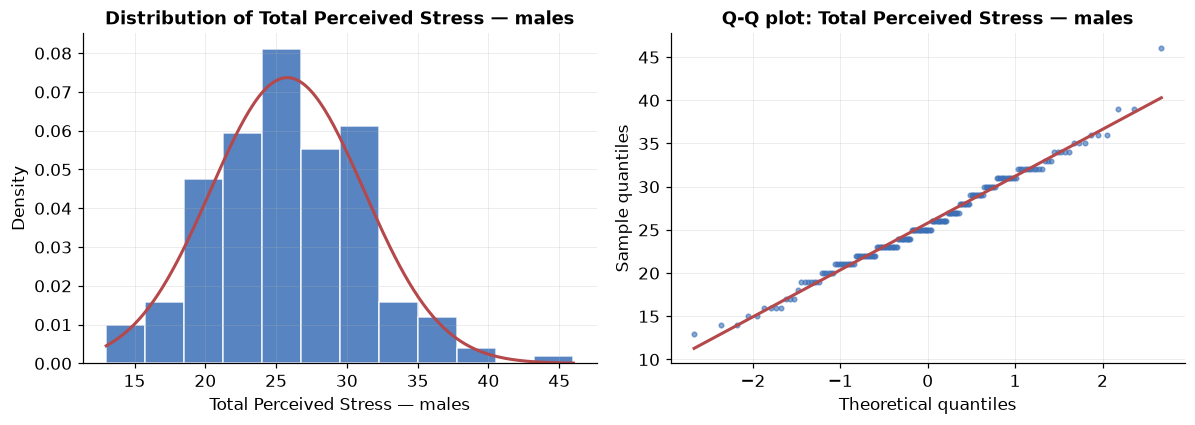

In [5]:
for level in ["FEMALES", "MALES"]:
    m9.normality_panel(survey.loc[survey.sex == level, "tpstress"],
                       label=f"Total Perceived Stress — {level.lower()}")

In [6]:
m9.report_normality(survey[survey.sex == "FEMALES"], "tpstress",
                    "Total Perceived Stress (women)")

Total Perceived Stress (women) was assessed for normality using the histogram and Q-Q plot above, supported by shape statistics (*N* = 249, *M* = 27.42, *SD* = 6.07). Skewness was 0.17 (standardised 1.12) and kurtosis 0.07 (standardised 0.24). At this sample size the standardised ratios are highly sensitive, so they are reported as descriptions of shape rather than as a pass/fail test. 0.0% of standardised scores fell beyond ±3.29, against about 0.1% expected under normality.

In [7]:
m9.report_normality(survey[survey.sex == "MALES"], "tpstress",
                    "Total Perceived Stress (men)")

Total Perceived Stress (men) was assessed for normality using the histogram and Q-Q plot above, supported by shape statistics (*N* = 184, *M* = 25.79, *SD* = 5.41). Skewness was 0.27 (standardised 1.51) and kurtosis 0.39 (standardised 1.10). The sample is small enough that these ratios have limited power, so the visual evidence carries most of the weight. 0.5% of standardised scores fell beyond ±3.29, against about 0.1% expected under normality.

Both groups are close to symmetric, the Q-Q plots follow the reference line
through the body of the distribution, and both samples are large. A *t*-test is
appropriate. We use Welch's version as standard, so no decision rests on a test
of equal variances.

### 1.4–1.5 Test and effect size

In [8]:
women = survey.loc[(survey.sex == "FEMALES") & survey.tpstress.notna(), "tpstress"]
men = survey.loc[(survey.sex == "MALES") & survey.tpstress.notna(), "tpstress"]

result = stats.ttest_ind(women, men, equal_var=False)
d = m9.cohens_d(women, men)
print(f"d = {d:.3f} ({m9.interpret(d, 'd')})")

d = 0.282 (small)


### 1.6 Report and conclude

In [9]:
m9.report_ttest(
    survey, "tpstress", "sex", result,
    outcome_label="Total Perceived Stress",
    group_labels={"FEMALES": "women", "MALES": "men"},
)

Welch's independent-samples *t*-test was conducted to compare Total Perceived Stress between women (*n* = 249, *M* = 27.42, *SD* = 6.07) and men (*n* = 184, *M* = 25.79, *SD* = 5.41). There was a statistically significant difference, *t*(415.9) = 2.95, *p* = .003, Cohen's *d* = 0.28 (small). Women scored 1.63 points higher on average.

**Conclusion.** There is evidence to reject the null hypothesis: women in this
sample reported higher perceived stress than men. The effect is small, so while
the difference is real in this sample it is modest in practical terms — the two
distributions overlap substantially, and knowing someone's sex would tell you
very little about their stress score.

---

## Question 2 — Negative affect by sex

### 2.1 Hypotheses

> **H₀:** There is no difference in Total Negative Affect between men and women.
>
> **H₁:** There is a difference in Total Negative Affect between men and women.

### 2.2 Inspect and check assumptions

In [10]:
m9.describe_by(survey, "tnegaff", "sex")

,n,missing,mean,sd,se,median,iqr,min,max,skew,kurtosis
sex,,,,,,,,,,,
FEMALES,250.0,4.0,19.940,7.169,0.453,18.0,9.75,10.0,39.0,0.777,-0.021
MALES,185.0,0.0,18.681,6.891,0.507,17.0,8.00,10.0,39.0,1.071,0.603


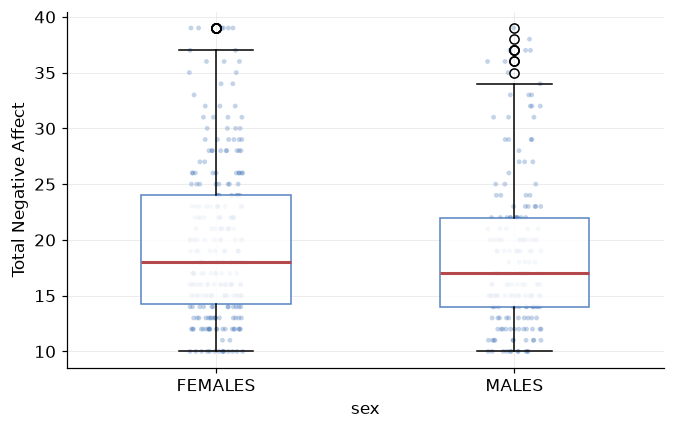

In [11]:
m9.grouped_box(survey, "tnegaff", "sex", ylabel="Total Negative Affect");

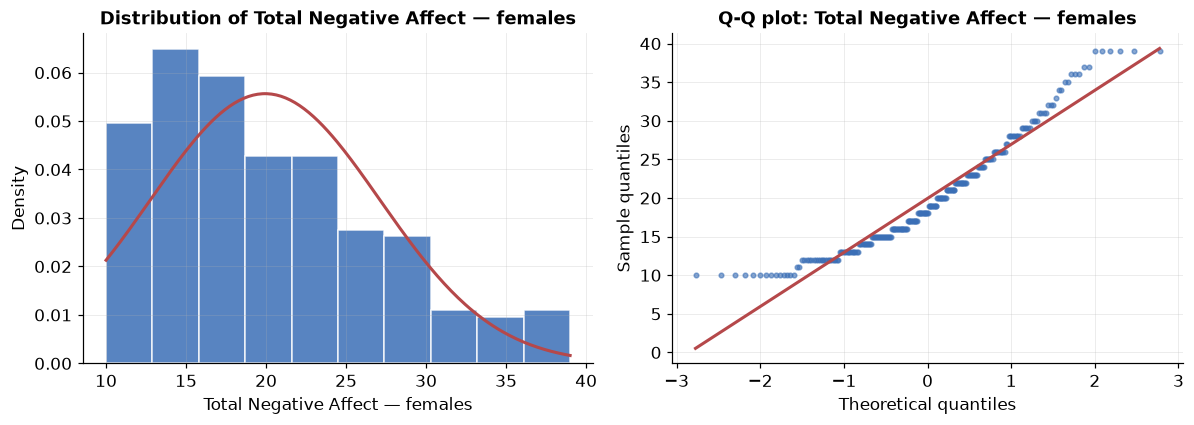

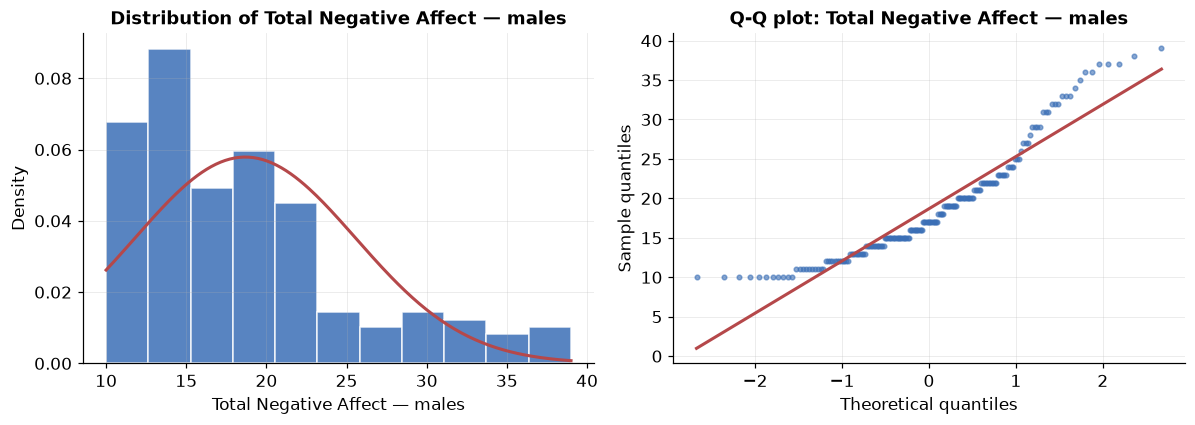

In [12]:
for level in ["FEMALES", "MALES"]:
    m9.normality_panel(survey.loc[survey.sex == level, "tnegaff"],
                       label=f"Total Negative Affect — {level.lower()}")

In [13]:
m9.report_normality(survey[survey.sex == "MALES"], "tnegaff",
                    "Total Negative Affect (men)")

Total Negative Affect (men) was assessed for normality using the histogram and Q-Q plot above, supported by shape statistics (*N* = 185, *M* = 18.68, *SD* = 6.89). Skewness was 1.07 (standardised 5.99) and kurtosis 0.60 (standardised 1.70). The sample is small enough that these ratios have limited power, so the visual evidence carries most of the weight. 0.0% of standardised scores fell beyond ±3.29, against about 0.1% expected under normality.

**What is different.** `tnegaff` is a bounded score with a floor: most people
report little negative affect, and a tail runs off to the right. Both groups are
positively skewed, visibly so in the histograms and as a curve away from the
line at the upper end of the Q-Q plots. Compare `tpstress`, which was close to
symmetric.

Because the outcome is skewed in both groups, a rank-based test is the safer
choice.

### 2.3–2.4 Test and effect size

In [14]:
women = survey.loc[(survey.sex == "FEMALES") & survey.tnegaff.notna(), "tnegaff"]
men = survey.loc[(survey.sex == "MALES") & survey.tnegaff.notna(), "tnegaff"]

mw = stats.mannwhitneyu(women, men, alternative="two-sided")
print(f"rank-biserial r = {m9.rank_biserial(women, men):.3f}")
print(f"Rosenthal's r   = {m9.wilcoxon_r(women, men):.3f}")

rank-biserial r = 0.111
Rosenthal's r   = 0.095


### 2.5 Report and conclude

In [15]:
m9.report_mannwhitney(
    survey, "tnegaff", "sex", mw,
    outcome_label="Total Negative Affect",
    group_labels={"FEMALES": "women", "MALES": "men"},
)

A Mann-Whitney *U* test was conducted to compare Total Negative Affect between women (*Mdn* = 18.00, *IQR* = 9.75) and men (*Mdn* = 17.00, *IQR* = 8.00). There was a statistically significant difference, *U* = 25691.0, *p* = .047, rank-biserial *r* = 0.11 (small). The test compares the whole distributions, so it supports a conclusion about which group tends to score higher rather than about the medians alone.

**The point of this question.** The p-value falls just below .05, so by the
conventional rule the result is "statistically significant" — and the effect
size sits barely above the boundary between negligible and small. Rescaling the
rank-biserial correlation shows what that means concretely:

In [16]:
r = m9.rank_biserial(women, men)
print(f"P(a randomly chosen woman scores above a randomly chosen man) "
      f"= {(r + 1) / 2:.1%}")

P(a randomly chosen woman scores above a randomly chosen man) = 55.5%


Against a coin-flip baseline of 50%, that is a very small edge.

**What to tell a non-statistician:** we can just about detect a difference,
because we have over four hundred people; but the difference is so small that
knowing whether someone is a man or a woman tells you almost nothing about their
negative affect score. A result can be statistically significant and practically
unimportant at the same time, which is why the effect size must always be
reported next to the p-value.

Note also how close this sits to the threshold. Had we collected a slightly
different sample, the p-value could easily have landed on the other side of .05.
That is a reason to report the number and the effect size and let the reader
judge, rather than treating .05 as a verdict.

---

## Question 3 — Bullying others by sex

### 3.1 Hypotheses

> **H₀:** Sex and reporting having bullied others are independent.
>
> **H₁:** Sex and reporting having bullied others are associated.

### 3.2 Inspect

In [17]:
pair = bully.dropna(subset=["rsex", "ubulloth"])
m9.crosstab(pair, "rsex", "ubulloth")

ubulloth,No,Yes
rsex,,
Female,448,21
Male,290,39


In [18]:
m9.crosstab(pair, "rsex", "ubulloth", normalize="index")

ubulloth,No,Yes
rsex,,
Female,95.5,4.5
Male,88.1,11.9


### 3.3 Assumptions

In [19]:
import pandas as pd

table = m9.crosstab(pair, "rsex", "ubulloth")
chi2, p, dof, expected = stats.chi2_contingency(table, correction=True)
pd.DataFrame(expected, index=table.index, columns=table.columns).round(1)

ubulloth,No,Yes
rsex,,
Female,433.7,35.3
Male,304.3,24.7


In [20]:
print(f"smallest expected count: {expected.min():.1f}")

smallest expected count: 24.7


All expected counts are comfortably above 5, so the chi-square approximation is
sound.

### 3.4 Report and conclude

In [21]:
m9.report_chisquare(
    table, (chi2, p, dof, expected),
    row_label="sex",
    col_label="having bullied others",
)

A chi-square test of independence examined the association between sex and having bullied others. There was a statistically significant association, χ²(1, *N* = 798) = 14.09, *p* < .001, Cramér's *V* = 0.138 (small).

**Conclusion.** There is evidence of an association between sex and reporting
having bullied others, with boys more likely to report it than girls. The effect
size is small. As with Question 1, the sample is large enough that a weak
association reaches significance, so the effect size is what tells you how much
the two variables actually travel together.

---

## Question 4 — Judgement

> "We tested whether our new interface reduces task completion time. A t-test
> was not significant (p = .08), so the two interfaces are equally fast."

**Three problems.**

1. **It accepts the null hypothesis.** A non-significant result is a failure to
   find sufficient evidence of a difference; it is not evidence that there is no
   difference. "Equally fast" is a claim the test cannot support.
2. **No effect size, and no descriptive statistics.** We are told nothing about
   how big the observed difference was, or how variable the times were. A p of
   .08 is equally consistent with a large difference measured imprecisely and a
   trivial one measured well — and those have opposite implications.
3. **A directional question answered with a bare verdict.** They asked whether
   the new interface *reduces* completion time, and report only "not
   significant" — no direction, no sample size, no confidence interval. The
   reader cannot tell whether the new interface was faster, slower, or
   indistinguishable, which is the question that was asked.

Also acceptable: treating .05 as a threshold that .08 decisively fails rather
than reporting the strength of evidence; and no mention of what the test
assumed. (The question says to take the *t*-test as appropriate, so its
assumptions are not the fault to lead with.)

**As it should have been reported:**

> Task completion time was compared between the current and new interfaces using
> Welch's independent-samples *t*-test. Completion times were lower with the new
> interface (*M* = …, *SD* = …, *n* = …) than the current one (*M* = …, *SD* = …,
> *n* = …), but the difference was not statistically significant,
> *t*(…) = …, *p* = .08, *d* = … (small), 95% CI [… , …]. The data do not provide
> sufficient evidence of a difference in completion time; the confidence interval
> is consistent with anything from a small slowdown to a moderate improvement, so
> a larger study would be needed to settle the question.